<a href="https://www.kaggle.com/code/lalit7881/frontier-ai-models-intelligence-hub-eda?scriptVersionId=340690165" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/saitejabandaruin/frontier-ai-models/stats.json
/kaggle/input/datasets/saitejabandaruin/frontier-ai-models/models.json
/kaggle/input/datasets/saitejabandaruin/frontier-ai-models/description.md
/kaggle/input/datasets/saitejabandaruin/frontier-ai-models/models.parquet
/kaggle/input/datasets/saitejabandaruin/frontier-ai-models/schema.json
/kaggle/input/datasets/saitejabandaruin/frontier-ai-models/metadata.json
/kaggle/input/datasets/saitejabandaruin/frontier-ai-models/benchmarks.csv
/kaggle/input/datasets/saitejabandaruin/frontier-ai-models/seed_models.csv
/kaggle/input/datasets/saitejabandaruin/frontier-ai-models/quality_report.json
/kaggle/input/datasets/saitejabandaruin/frontier-ai-models/frontier_ai_hub.sqlite
/kaggle/input/datasets/saitejabandaruin/frontier-ai-models/providers.csv
/kaggle/input/datasets/saitejabandaruin/frontier-ai-models/models.csv
/kaggle/input/datasets/saitejabandaruin/frontier-ai-models/quality_report.md


In [2]:
import json
import sqlite3
import os

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

# Dataset Path
DATASET_PATH = "/kaggle/input/datasets/saitejabandaruin/frontier-ai-models"

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


## LOading dataset

In [3]:
models_csv = pd.read_csv(f"{DATASET_PATH}/models.csv")
providers = pd.read_csv(f"{DATASET_PATH}/providers.csv")
benchmarks = pd.read_csv(f"{DATASET_PATH}/benchmarks.csv")
seed_models = pd.read_csv(f"{DATASET_PATH}/seed_models.csv")

print("CSV Files Loaded")

CSV Files Loaded


In [4]:
models_parquet = pd.read_parquet(f"{DATASET_PATH}/models.parquet")

print("Parquet Loaded")

Parquet Loaded


In [5]:
def load_json(path):
    with open(path, "r") as f:
        return json.load(f)

stats = load_json(f"{DATASET_PATH}/stats.json")
metadata = load_json(f"{DATASET_PATH}/metadata.json")
schema = load_json(f"{DATASET_PATH}/schema.json")
quality_report = load_json(f"{DATASET_PATH}/quality_report.json")

print("JSON Files Loaded")

JSON Files Loaded


In [6]:
stats_df = pd.json_normalize(stats)
metadata_df = pd.json_normalize(metadata)
schema_df = pd.json_normalize(schema)
quality_df = pd.json_normalize(quality_report)

print("JSON Converted to DataFrames")

JSON Converted to DataFrames


In [7]:
with open(f"{DATASET_PATH}/description.md", "r") as file:
    description = file.read()

print(description[:1000])

# 🚀 Frontier AI Models Intelligence Hub: The Ultimate LLM Database

### 🌟 Context & Overview
The Generative AI landscape is moving at breakneck speed. Every week, new Large Language Models (LLMs), multimodal foundation models, and open-source challengers are released. Keeping track of **context windows, API pricing, benchmark scores, and architectural capabilities** has become nearly impossible—until now.

The **Frontier AI Models Intelligence Hub** is the world's most comprehensive, continuously updated dataset of modern AI models. Whether you are an AI researcher, a Data Scientist, an MLOps Engineer, or a developer trying to choose the most cost-effective model for your production application, this dataset provides the definitive ground truth.

### 📊 What's Inside?
This dataset offers an unprecedented **130+ columns of rich metadata** across multiple highly-structured relational tables, exported in 9 different formats (CSV, Parquet, JSON, SQLite, etc.) for your convenience. 

We trac

In [8]:
conn = sqlite3.connect(f"{DATASET_PATH}/frontier_ai_hub.sqlite")

tables = pd.read_sql(
    "SELECT name FROM sqlite_master WHERE type='table';",
    conn
)

print("Tables in Database")
print(tables)

Tables in Database
         name
0      models
1   providers
2  benchmarks


In [9]:
database_tables = {}

for table in tables["name"]:
    database_tables[table] = pd.read_sql(f"SELECT * FROM {table}", conn)

print("Loaded Database Tables")

for name, df in database_tables.items():
    print(f"{name} : {df.shape}")

Loaded Database Tables
models : (90, 130)
providers : (17, 9)
benchmarks : (720, 6)


In [10]:
datasets = {
    "Models CSV": models_csv,
    "Providers": providers,
    "Benchmarks": benchmarks,
    "Seed Models": seed_models,
    "Models Parquet": models_parquet,
    "Stats": stats_df,
    "Metadata": metadata_df,
    "Schema": schema_df,
    "Quality": quality_df
}

for name, df in datasets.items():
    print("="*70)
    print(name)
    print("="*70)
    print("Shape :", df.shape)
    print(df.head())

Models CSV
Shape : (90, 130)
               model_id       model_name       model_slug provider_id  \
0          01.ai/yi-34b           Yi-34B           yi-34b       01.ai   
1           01.ai/yi-6b            Yi-6B            yi-6b       01.ai   
2        01.ai/yi-large         Yi-Large         yi-large       01.ai   
3       01.ai/yi-medium        Yi-Medium        yi-medium       01.ai   
4  ai21/jamba-1-5-large  Jamba-1-5-Large  jamba-1-5-large        ai21   

  provider_name release_date  version model_family  model_generation  \
0         01.AI   2023-11-06      1.0           yi               NaN   
1         01.AI   2023-11-06      1.0           yi               NaN   
2         01.AI   2024-05-01      1.0           yi               NaN   
3         01.AI   2024-05-01      1.0           yi               NaN   
4     AI21 Labs   2024-08-01      1.0        jamba               NaN   

   is_latest_version architecture_type  parameter_count_b  \
0               True       Transformer

In [11]:
for name, df in datasets.items():
    print("\n", "="*60)
    print(name)
    print("="*60)
    print(df.isnull().sum())


Models CSV
model_id                    0
model_name                  0
model_slug                  0
provider_id                 0
provider_name               0
                           ..
benchmark_knowledge_avg     0
benchmark_coding_avg        0
benchmark_vision_avg       90
benchmark_overall_avg       0
days_since_release          0
Length: 130, dtype: int64

Providers
provider_name           0
model_count             0
open_source_count       0
open_weights_count      0
avg_price_input_usd     0
avg_price_output_usd    0
max_context_window      0
vision_models_count     0
latest_release_date     0
dtype: int64

Benchmarks
model_id          0
model_name        0
provider_name     0
benchmark_name    0
benchmark_col     0
score             0
dtype: int64

Seed Models
model_id               0
model_name             0
model_slug             0
provider_id            0
provider_name          0
                      ..
is_deprecated          0
deprecation_date      90
successor_model_

In [12]:
for name, df in datasets.items():
    print("\n", "="*60)
    print(name)
    print("="*60)
    print(df.dtypes)


Models CSV
model_id                    object
model_name                  object
model_slug                  object
provider_id                 object
provider_name               object
                            ...   
benchmark_knowledge_avg    float64
benchmark_coding_avg       float64
benchmark_vision_avg       float64
benchmark_overall_avg      float64
days_since_release           int64
Length: 130, dtype: object

Providers
provider_name            object
model_count               int64
open_source_count         int64
open_weights_count        int64
avg_price_input_usd     float64
avg_price_output_usd    float64
max_context_window        int64
vision_models_count       int64
latest_release_date      object
dtype: object

Benchmarks
model_id           object
model_name         object
provider_name      object
benchmark_name     object
benchmark_col      object
score             float64
dtype: object

Seed Models
model_id               object
model_name             object
model_sl

In [13]:
for name, df in datasets.items():
    print("\n", "="*60)
    print(name)
    print("="*60)
    print(df.describe(include="all"))


Models CSV
            model_id model_name model_slug provider_id provider_name  \
count             90         90         90          90            90   
unique            90         90         90          17            17   
top     01.ai/yi-34b     Yi-34B     yi-34b      openai        OpenAI   
freq               1          1          1          12            12   
mean             NaN        NaN        NaN         NaN           NaN   
std              NaN        NaN        NaN         NaN           NaN   
min              NaN        NaN        NaN         NaN           NaN   
25%              NaN        NaN        NaN         NaN           NaN   
50%              NaN        NaN        NaN         NaN           NaN   
75%              NaN        NaN        NaN         NaN           NaN   
max              NaN        NaN        NaN         NaN           NaN   

       release_date  version model_family  model_generation is_latest_version  \
count            90     90.0           90 

In [14]:
for name, df in datasets.items():

    # Create a copy
    temp_df = df.copy()

    # Convert list/dict/set columns into strings
    for col in temp_df.columns:
        temp_df[col] = temp_df[col].apply(
            lambda x: str(x) if isinstance(x, (list, dict, set)) else x
        )

    duplicates = temp_df.duplicated().sum()

    print(f"{name} -> Duplicates: {duplicates}")

Models CSV -> Duplicates: 0
Providers -> Duplicates: 0
Benchmarks -> Duplicates: 0
Seed Models -> Duplicates: 0
Models Parquet -> Duplicates: 0
Stats -> Duplicates: 0
Metadata -> Duplicates: 0
Schema -> Duplicates: 0
Quality -> Duplicates: 0


In [15]:
for name, df in datasets.items():
    print("\n", "="*60)
    print(name)
    print("="*60)
    print(df.describe(include="all"))


Models CSV
            model_id model_name model_slug provider_id provider_name  \
count             90         90         90          90            90   
unique            90         90         90          17            17   
top     01.ai/yi-34b     Yi-34B     yi-34b      openai        OpenAI   
freq               1          1          1          12            12   
mean             NaN        NaN        NaN         NaN           NaN   
std              NaN        NaN        NaN         NaN           NaN   
min              NaN        NaN        NaN         NaN           NaN   
25%              NaN        NaN        NaN         NaN           NaN   
50%              NaN        NaN        NaN         NaN           NaN   
75%              NaN        NaN        NaN         NaN           NaN   
max              NaN        NaN        NaN         NaN           NaN   

       release_date  version model_family  model_generation is_latest_version  \
count            90     90.0           90 

## EDA

In [16]:
import plotly.express as px

plt.rcParams["figure.figsize"] = (10,5)

pd.set_option("display.max_columns",None)

In [17]:
df = models_csv.copy()

print(df.shape)

df.head()

(90, 130)


,model_id,model_name,model_slug,provider_id,provider_name,release_date,version,model_family,model_generation,is_latest_version,architecture_type,parameter_count_b,parameter_count_active_b,num_layers,num_attention_heads,context_window_tokens,training_tokens_b,mixture_of_experts,num_experts,expert_routing_strategy,supports_text_input,supports_image_input,supports_audio_input,supports_video_input,supports_document_input,supports_text_output,supports_image_output,supports_audio_output,supports_code,supports_function_calling,supports_structured_output,supports_streaming,price_input_per_1m_tokens_usd,price_output_per_1m_tokens_usd,price_cached_input_per_1m_tokens_usd,price_image_input_per_image_usd,price_audio_input_per_min_usd,price_fine_tuning_input_usd,price_fine_tuning_output_usd,price_batch_input_usd,price_batch_output_usd,has_free_tier,free_tier_limit_description,pricing_last_updated,throughput_tokens_per_sec,latency_first_token_ms,latency_p50_ms,latency_p90_ms,max_output_tokens,requests_per_minute_limit,tokens_per_minute_limit,supports_parallel_requests,inference_provider,deployment_region,bench_mmlu_score,bench_mmlu_pro_score,bench_gpqa_diamond_score,bench_gpqa_main_score,bench_aime_2024_score,bench_aime_2025_score,bench_math_score,bench_gsm8k_score,bench_arc_challenge_score,bench_hellaswag_score,bench_winogrande_score,bench_bbh_score,bench_ifeval_score,bench_truthfulqa_score,bench_humaneval_score,bench_mbpp_score,bench_swe_bench_verified_score,bench_swe_bench_lite_score,bench_livecodebench_score,bench_polyglot_score,bench_ds1000_score,bench_codeforces_rating,bench_mmmu_score,bench_mmmu_pro_score,bench_mathvista_score,bench_chartqa_score,bench_docvqa_score,bench_vqa_score,bench_livebench_vision_score,bench_video_mme_score,bench_livebench_overall_score,bench_helm_overall_score,bench_artificial_analysis_quality_score,bench_lmarena_elo,bench_chatbot_arena_elo,bench_overall_rank,is_open_source,is_open_weights,model_license,license_commercial_use,license_derivatives_allowed,huggingface_model_id,huggingface_downloads_30d,huggingface_likes,github_repo_url,github_stars,paper_title,paper_arxiv_id,paper_url,paper_published_date,paper_citation_count,papers_with_code_url,knowledge_cutoff_date,training_data_description,data_source_primary,data_sources_all,data_collected_at,data_freshness_score,record_version,record_created_at,record_updated_at,is_deprecated,deprecation_date,successor_model_id,quality_score,completeness_pct,price_ratio_output_to_input,cost_per_1k_tokens_balanced,multimodal_score,is_multimodal,capability_count,benchmark_knowledge_avg,benchmark_coding_avg,benchmark_vision_avg,benchmark_overall_avg,days_since_release
0,01.ai/yi-34b,Yi-34B,yi-34b,01.ai,01.AI,2023-11-06,1.0,yi,NaN,True,Transformer,NaN,NaN,NaN,NaN,8192,NaN,False,NaN,NaN,True,False,False,False,False,True,False,False,True,True,True,True,4.04,15.81,4.55,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,2025-01-01,56.8,1212.0,NaN,NaN,4096,NaN,NaN,True,01.AI,us-east-1,67.0,61.2,35.9,NaN,NaN,NaN,64.7,91.5,NaN,NaN,NaN,NaN,NaN,NaN,53.5,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1104.0,1168.0,NaN,True,True,Apache 2.0,True,True,01.ai/yi-34b,203862.0,6390.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-01,NaN,Web,Web,2025-01-01,1.0,1.0,2025-01-01,2025-01-01,False,NaN,NaN,95.0,51.7,3.913366,0.009925,0,False,7,64.775,53.5,NaN,330.7250,1004
1,01.ai/yi-6b,Yi-6B,yi-6b,01.ai,01.AI,2023-11-06,1.0,yi,NaN,True,Transformer,7.0,NaN,NaN,NaN,8192,NaN,False,NaN,NaN,True,False,False,False,False,True,False,False,True,True,True,True,11.34,29.73,2.55,NaN,NaN,NaN,NaN,NaN,NaN,False,NaN,2025-01-01,78.1,829.0,NaN,NaN,4096,NaN,NaN,True,01.AI,us-east-1,67.2,44.0,51.0,NaN,NaN,NaN,46.2,71.7,NaN,NaN,NaN,NaN,NaN,NaN,71.4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1245.0,1269.0,NaN,True,True,Apache 2.0,True,True,01.ai/yi-6b,919103.0,9905.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2023-12-01,NaN,Web,Web,2025-01-01,1.0,1.0,2025-01-01,2025-01-01,False,NaN,NaN,95.0,52.5,2.62169

In [18]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90 entries, 0 to 89
Columns: 130 entries, model_id to days_since_release
dtypes: bool(22), float64(84), int64(5), object(19)
memory usage: 78.0+ KB
None


In [19]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model_id,90,90,01.ai/yi-34b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_name,90,90,Yi-34B,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_slug,90,90,yi-34b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provider_id,90,17,openai,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provider_name,90,17,OpenAI,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
benchmark_knowledge_avg,90.0,NaN,NaN,NaN,64.838889,5.440719,53.475,61.09375,64.6625,67.8625,79.475
benchmark_coding_avg,90.0,NaN,NaN,NaN,63.278889,14.59072,40.2,50.325,62.15,76.075,90.5
benchmark_vision_avg,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benchmark_overall_avg,90.0,NaN,NaN,NaN,347.972361,10.64361,324.05,339.053125,348.4375,356.496875,370.9375


In [20]:
df.describe(include='all').T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model_id,90,90,01.ai/yi-34b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_name,90,90,Yi-34B,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_slug,90,90,yi-34b,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provider_id,90,17,openai,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provider_name,90,17,OpenAI,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
benchmark_knowledge_avg,90.0,NaN,NaN,NaN,64.838889,5.440719,53.475,61.09375,64.6625,67.8625,79.475
benchmark_coding_avg,90.0,NaN,NaN,NaN,63.278889,14.59072,40.2,50.325,62.15,76.075,90.5
benchmark_vision_avg,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benchmark_overall_avg,90.0,NaN,NaN,NaN,347.972361,10.64361,324.05,339.053125,348.4375,356.496875,370.9375


In [21]:
missing = pd.DataFrame({
    "Missing Values":df.isnull().sum(),
    "Percentage":round(df.isnull().mean()*100,2)
})

missing.sort_values("Percentage",ascending=False)

,Missing Values,Percentage
training_tokens_b,90,100.0
model_generation,90,100.0
github_repo_url,90,100.0
github_stars,90,100.0
parameter_count_active_b,90,100.0
...,...,...
is_multimodal,0,0.0
benchmark_knowledge_avg,0,0.0
benchmark_coding_avg,0,0.0
benchmark_overall_avg,0,0.0


In [22]:
temp = df.copy()

temp = temp.map(
    lambda x: str(x) if isinstance(x,(list,dict,set)) else x
)

print("Duplicate Rows :",temp.duplicated().sum())

Duplicate Rows : 0


In [23]:
dtype = pd.DataFrame(df.dtypes,columns=["Datatype"])

dtype

,Datatype
model_id,object
model_name,object
model_slug,object
provider_id,object
provider_name,object
...,...
benchmark_knowledge_avg,float64
benchmark_coding_avg,float64
benchmark_vision_avg,float64
benchmark_overall_avg,float64


In [24]:
num_cols = df.select_dtypes(include=np.number).columns

print(num_cols.tolist())


['version', 'model_generation', 'parameter_count_b', 'parameter_count_active_b', 'num_layers', 'num_attention_heads', 'context_window_tokens', 'training_tokens_b', 'num_experts', 'expert_routing_strategy', 'price_input_per_1m_tokens_usd', 'price_output_per_1m_tokens_usd', 'price_cached_input_per_1m_tokens_usd', 'price_image_input_per_image_usd', 'price_audio_input_per_min_usd', 'price_fine_tuning_input_usd', 'price_fine_tuning_output_usd', 'price_batch_input_usd', 'price_batch_output_usd', 'free_tier_limit_description', 'throughput_tokens_per_sec', 'latency_first_token_ms', 'latency_p50_ms', 'latency_p90_ms', 'max_output_tokens', 'requests_per_minute_limit', 'tokens_per_minute_limit', 'bench_mmlu_score', 'bench_mmlu_pro_score', 'bench_gpqa_diamond_score', 'bench_gpqa_main_score', 'bench_aime_2024_score', 'bench_aime_2025_score', 'bench_math_score', 'bench_gsm8k_score', 'bench_arc_challenge_score', 'bench_hellaswag_score', 'bench_winogrande_score', 'bench_bbh_score', 'bench_ifeval_score

In [25]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
version,90.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
model_generation,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parameter_count_b,57.0,167.157895,184.610090,7.000000,13.000000,70.000000,405.000000,405.000000
parameter_count_active_b,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_layers,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_attention_heads,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
context_window_tokens,90.0,112500.622222,266559.273142,8192.000000,8192.000000,8192.000000,8192.000000,1000000.000000
training_tokens_b,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_experts,4.0,8.000000,0.000000,8.000000,8.000000,8.000000,8.000000,8.000000
expert_routing_strategy,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [26]:
corr = df[num_cols].corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="Viridis",
    title="Correlation Matrix"
)

fig.show()

In [27]:
for col in num_cols:

    fig = px.histogram(
        df,
        x=col,
        nbins=30,
        title=f"{col} Distribution"
    )

    fig.show()

In [28]:
for col in num_cols:

    fig = px.box(
        df,
        y=col,
        title=f"{col} Boxplot"
    )

    fig.show()

In [29]:
cat_cols = df.select_dtypes(include="object").columns

print(cat_cols.tolist())

['model_id', 'model_name', 'model_slug', 'provider_id', 'provider_name', 'release_date', 'model_family', 'architecture_type', 'pricing_last_updated', 'inference_provider', 'deployment_region', 'model_license', 'huggingface_model_id', 'knowledge_cutoff_date', 'data_source_primary', 'data_sources_all', 'data_collected_at', 'record_created_at', 'record_updated_at']


In [30]:
for col in cat_cols[:10]:

    value = df[col].astype(str).value_counts().head(20)

    fig = px.bar(
        x=value.index,
        y=value.values,
        title=col
    )

    fig.show()

In [31]:
for col in cat_cols[:5]:

    value = df[col].astype(str).value_counts().head(10)

    fig = px.pie(
        names=value.index,
        values=value.values,
        title=col
    )

    fig.show()

In [32]:
df[num_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
version,90.0,1.000000,0.000000,1.000000,1.000000,1.000000,1.000000,1.000000
model_generation,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
parameter_count_b,57.0,167.157895,184.610090,7.000000,13.000000,70.000000,405.000000,405.000000
parameter_count_active_b,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_layers,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_attention_heads,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
context_window_tokens,90.0,112500.622222,266559.273142,8192.000000,8192.000000,8192.000000,8192.000000,1000000.000000
training_tokens_b,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
num_experts,4.0,8.000000,0.000000,8.000000,8.000000,8.000000,8.000000,8.000000
expert_routing_strategy,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [33]:
corr = df[num_cols].corr(numeric_only=True)

fig = px.imshow(
    corr,
    text_auto=True,
    color_continuous_scale="Viridis",
    title="Correlation Matrix"
)

fig.show()

In [34]:
for col in num_cols:

    fig = px.histogram(
        df,
        x=col,
        nbins=30,
        title=f"{col} Distribution"
    )

    fig.show()

In [35]:
for col in num_cols:

    fig = px.box(
        df,
        y=col,
        title=f"{col} Boxplot"
    )

    fig.show()

In [36]:
for col in cat_cols[:10]:

    value = df[col].astype(str).value_counts().head(20)

    fig = px.bar(
        x=value.index,
        y=value.values,
        title=col
    )

    fig.show()

In [37]:
for col in cat_cols[:10]:

    value = df[col].astype(str).value_counts().head(20)

    fig = px.bar(
        x=value.index,
        y=value.values,
        title=col
    )

    fig.show()

In [38]:
for col in cat_cols[:5]:

    value = df[col].astype(str).value_counts().head(10)

    fig = px.pie(
        names=value.index,
        values=value.values,
        title=col
    )

    fig.show()

In [39]:
unique = pd.DataFrame({
    "Column":df.columns,
    "Unique Values":[df[col].nunique() for col in df.columns]
})

unique

,Column,Unique Values
0,model_id,90
1,model_name,90
2,model_slug,90
3,provider_id,17
4,provider_name,17
...,...,...
125,benchmark_knowledge_avg,85
126,benchmark_coding_avg,85
127,benchmark_vision_avg,0
128,benchmark_overall_avg,90


In [40]:
for col in num_cols:

    Q1=df[col].quantile(0.25)

    Q3=df[col].quantile(0.75)

    IQR=Q3-Q1

    lower=Q1-1.5*IQR

    upper=Q3+1.5*IQR

    out=((df[col]<lower)|(df[col]>upper)).sum()

    print(col," :",out)

version  : 0
model_generation  : 0
parameter_count_b  : 0
parameter_count_active_b  : 0
num_layers  : 0
num_attention_heads  : 0
context_window_tokens  : 22
training_tokens_b  : 0
num_experts  : 0
expert_routing_strategy  : 0
price_input_per_1m_tokens_usd  : 0
price_output_per_1m_tokens_usd  : 0
price_cached_input_per_1m_tokens_usd  : 0
price_image_input_per_image_usd  : 0
price_audio_input_per_min_usd  : 0
price_fine_tuning_input_usd  : 0
price_fine_tuning_output_usd  : 0
price_batch_input_usd  : 0
price_batch_output_usd  : 0
free_tier_limit_description  : 0
throughput_tokens_per_sec  : 0
latency_first_token_ms  : 0
latency_p50_ms  : 0
latency_p90_ms  : 0
max_output_tokens  : 0
requests_per_minute_limit  : 0
tokens_per_minute_limit  : 0
bench_mmlu_score  : 0
bench_mmlu_pro_score  : 0
bench_gpqa_diamond_score  : 0
bench_gpqa_main_score  : 0
bench_aime_2024_score  : 0
bench_aime_2025_score  : 0
bench_math_score  : 0
bench_gsm8k_score  : 0
bench_arc_challenge_score  : 0
bench_hellaswag_s

In [41]:
pd.DataFrame(df[num_cols].skew(),columns=["Skewness"])

,Skewness
version,0.000000
model_generation,NaN
parameter_count_b,0.516314
parameter_count_active_b,NaN
num_layers,NaN
num_attention_heads,NaN
context_window_tokens,2.925715
training_tokens_b,NaN
num_experts,0.000000
expert_routing_strategy,NaN


In [42]:
pd.DataFrame(df[num_cols].kurt(),columns=["Kurtosis"])

,Kurtosis
version,0.000000
model_generation,NaN
parameter_count_b,-1.740106
parameter_count_active_b,NaN
num_layers,NaN
num_attention_heads,NaN
context_window_tokens,7.255784
training_tokens_b,NaN
num_experts,0.000000
expert_routing_strategy,NaN


In [43]:
if "provider" in df.columns:

    fig=px.bar(
        df["provider"].value_counts().head(20),
        title="Top Providers"
    )

    fig.show()

In [44]:
if "benchmark" in benchmarks.columns:

    fig=px.bar(
        benchmarks["benchmark"].value_counts(),
        title="Benchmark Count"
    )

    fig.show()
    

In [45]:
providers.head()

providers.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
provider_name,17,17,OpenAI,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_count,17.0,NaN,NaN,NaN,5.294118,3.584074,1.0,3.0,4.0,9.0,12.0
open_source_count,17.0,NaN,NaN,NaN,2.941176,3.230143,0.0,0.0,2.0,4.0,9.0
open_weights_count,17.0,NaN,NaN,NaN,2.941176,3.230143,0.0,0.0,2.0,4.0,9.0
avg_price_input_usd,17.0,NaN,NaN,NaN,6.767787,2.178256,2.74,5.893333,6.836667,8.5875,9.210909
avg_price_output_usd,17.0,NaN,NaN,NaN,12.423508,6.448306,0.5,8.835556,13.356667,14.358,26.97
max_context_window,17.0,NaN,NaN,NaN,84864.0,241724.436299,8192.0,8192.0,8192.0,8192.0,1000000.0
vision_models_count,17.0,NaN,NaN,NaN,0.588235,1.734172,0.0,0.0,0.0,0.0,7.0
latest_release_date,17,16,2024-12-01,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [46]:
benchmarks.head()

benchmarks.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model_id,720,90,01.ai/yi-34b,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_name,720,90,Yi-34B,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provider_name,720,17,OpenAI,96,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benchmark_name,720,8,mmlu,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
benchmark_col,720,8,bench_mmlu_score,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
score,720.0,NaN,NaN,NaN,347.972361,494.627342,30.3,54.15,71.9,346.425,1300.0


In [47]:
seed_models.head()

seed_models.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
model_id,90,90,openai/gpt-4o,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_name,90,90,Gpt-4O,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
model_slug,90,90,gpt-4o,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provider_id,90,17,openai,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
provider_name,90,17,OpenAI,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
is_deprecated,90,1,False,90,NaN,NaN,NaN,NaN,NaN,NaN,NaN
deprecation_date,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
successor_model_id,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
quality_score,90.0,NaN,NaN,NaN,95.0,0.0,95.0,95.0,95.0,95.0,95.0


In [48]:
summary = pd.DataFrame({

    "Rows":[models_csv.shape[0],
            providers.shape[0],
            benchmarks.shape[0],
            seed_models.shape[0]],

    "Columns":[models_csv.shape[1],
               providers.shape[1],
               benchmarks.shape[1],
               seed_models.shape[1]]

},

index=["Models","Providers","Benchmarks","Seed Models"])

summary

,Rows,Columns
Models,90,130
Providers,17,9
Benchmarks,720,6
Seed Models,90,120


## Feature engineering

In [49]:
print(models_csv.columns.tolist())

['model_id', 'model_name', 'model_slug', 'provider_id', 'provider_name', 'release_date', 'version', 'model_family', 'model_generation', 'is_latest_version', 'architecture_type', 'parameter_count_b', 'parameter_count_active_b', 'num_layers', 'num_attention_heads', 'context_window_tokens', 'training_tokens_b', 'mixture_of_experts', 'num_experts', 'expert_routing_strategy', 'supports_text_input', 'supports_image_input', 'supports_audio_input', 'supports_video_input', 'supports_document_input', 'supports_text_output', 'supports_image_output', 'supports_audio_output', 'supports_code', 'supports_function_calling', 'supports_structured_output', 'supports_streaming', 'price_input_per_1m_tokens_usd', 'price_output_per_1m_tokens_usd', 'price_cached_input_per_1m_tokens_usd', 'price_image_input_per_image_usd', 'price_audio_input_per_min_usd', 'price_fine_tuning_input_usd', 'price_fine_tuning_output_usd', 'price_batch_input_usd', 'price_batch_output_usd', 'has_free_tier', 'free_tier_limit_descripti

In [50]:
target = "is_open_source"

In [51]:
# -------------------------------
# Drop unnecessary columns
# -------------------------------
drop_cols = [
    'model_id',
    'model_name',
    'model_slug',
    'github_repo_url',
    'paper_url',
    'paper_title',
    'paper_arxiv_id',
    'papers_with_code_url',
    'training_data_description',
    'data_sources_all'
]

df.drop(columns=drop_cols, inplace=True, errors='ignore')

# -------------------------------
# Convert dates
# -------------------------------
date_cols = [
    'release_date',
    'pricing_last_updated',
    'paper_published_date',
    'knowledge_cutoff_date',
    'data_collected_at',
    'record_created_at',
    'record_updated_at',
    'deprecation_date'
]

for col in date_cols:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')
        df[col+"_year"] = df[col].dt.year
        df[col+"_month"] = df[col].dt.month
        df[col+"_day"] = df[col].dt.day

df.drop(columns=date_cols, inplace=True, errors='ignore')

In [52]:
num_cols = df.select_dtypes(include=np.number).columns

cat_cols = df.select_dtypes(include='object').columns

df[num_cols] = df[num_cols].fillna(df[num_cols].median())

for col in cat_cols:
    df[col] = df[col].fillna(df[col].mode()[0])

In [53]:
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

for col in cat_cols:
    df[col] = encoder.fit_transform(df[col].astype(str))

In [54]:
target = "is_open_source"

X = df.drop(target, axis=1)

y = df[target]

In [55]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(72, 135)
(18, 135)


In [56]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

In [57]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB

models = {

    "Logistic Regression": LogisticRegression(max_iter=500),

    "Decision Tree": DecisionTreeClassifier(),

    "Random Forest": RandomForestClassifier(),

    "Extra Trees": ExtraTreesClassifier(),

    "Gradient Boosting": GradientBoostingClassifier(),

    "KNN": KNeighborsClassifier(),

    "SVM": SVC(),

    "Naive Bayes": GaussianNB()

}

In [58]:
print("Total Missing Values:", X.isnull().sum().sum())

missing = X.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)

print(missing)

Total Missing Values: 4950
model_generation                           90
parameter_count_active_b                   90
num_layers                                 90
num_attention_heads                        90
training_tokens_b                          90
expert_routing_strategy                    90
price_image_input_per_image_usd            90
price_audio_input_per_min_usd              90
price_fine_tuning_input_usd                90
price_fine_tuning_output_usd               90
price_batch_input_usd                      90
price_batch_output_usd                     90
free_tier_limit_description                90
latency_p50_ms                             90
latency_p90_ms                             90
requests_per_minute_limit                  90
tokens_per_minute_limit                    90
bench_gpqa_main_score                      90
bench_aime_2024_score                      90
bench_aime_2025_score                      90
bench_arc_challenge_score                  90
bench_h

In [59]:
# Drop columns having more than 50% missing values
threshold = len(df) * 0.5

df = df.dropna(axis=1, thresh=threshold)

print("Remaining Columns:", df.shape[1])

Remaining Columns: 81


In [60]:
# Numeric columns
num_cols = df.select_dtypes(include=np.number).columns

# Categorical columns
cat_cols = df.select_dtypes(include=["object", "category", "bool"]).columns

# Fill numeric
for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical
for col in cat_cols:
    mode = df[col].mode()
    if len(mode) > 0:
        df[col] = df[col].fillna(mode[0])
    else:
        df[col] = df[col].fillna("Unknown")

In [61]:
df = df.replace([np.inf, -np.inf], np.nan)

# Fill again
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

In [62]:
df = df.loc[:, df.nunique() > 1]

In [63]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for col in df.select_dtypes(include="object").columns:
    df[col] = le.fit_transform(df[col].astype(str))
    

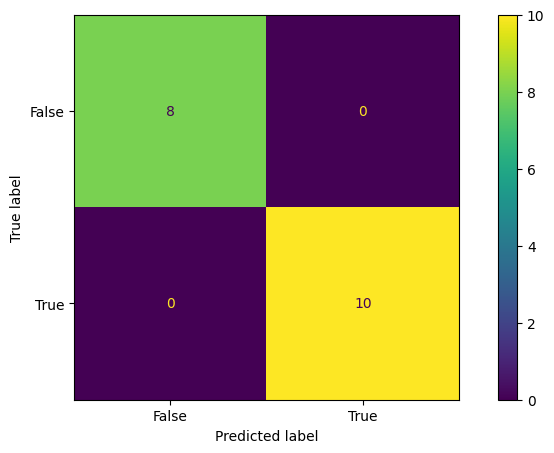

In [64]:
from sklearn.metrics import ConfusionMatrixDisplay

best_model = RandomForestClassifier()

best_model.fit(X_train,y_train)

ConfusionMatrixDisplay.from_estimator(
    best_model,
    X_test,
    y_test
)

In [65]:
from sklearn.metrics import classification_report

pred = best_model.predict(X_test)

print(classification_report(y_test,pred))

              precision    recall  f1-score   support

       False       1.00      1.00      1.00         8
        True       1.00      1.00      1.00        10

    accuracy                           1.00        18
   macro avg       1.00      1.00      1.00        18
weighted avg       1.00      1.00      1.00        18



In [66]:
importance = pd.DataFrame({

    "Feature":X.columns,

    "Importance":best_model.feature_importances_

})

importance.sort_values(
    by="Importance",
    ascending=False
).head(20)

,Feature,Importance
85,is_open_weights,0.166722
86,model_license,0.158524
100,completeness_pct,0.139946
88,license_derivatives_allowed,0.111602
47,inference_provider,0.037799
89,huggingface_model_id,0.036107
91,huggingface_likes,0.033129
20,supports_document_input,0.025829
11,context_window_tokens,0.025183
0,provider_id,0.024635


## Thank you... pls upvote!!!!!!!!